# Báo Cáo Nghiên Cứu: Nhu cầu Tuyển dụng & Khoảng cách Kỹ năng IT

Dự án này thực hiện việc thu thập dữ liệu tuyển dụng IT từ TopDev, ITviec và VietnamWorks để phân tích xu hướng thị trường công nghệ và khoảng cách kỹ năng giữa sinh viên mới ra trường và yêu cầu doanh nghiệp.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import ast

# Cấu hình hiển thị biểu đồ inline
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

## 1. Đọc và Xử lý dữ liệu đã làm sạch

Chúng ta đọc dữ liệu đã được gộp và làm sạch từ file `data/processed/all_jobs_final_analysis_filtered.csv`.

In [2]:
# Đọc dữ liệu
df = pd.read_csv('data/processed/all_jobs_final_analysis_filtered.csv', encoding='utf-8')

# Parse các cột dạng list string sang list thực tế
def safe_eval(val):
    if pd.isna(val):
        return []
    val_str = str(val).strip()
    if not val_str or val_str.lower() in {'nan', 'none', '[]'}:
        return []
    try:
        res = ast.literal_eval(val_str)
        return res if isinstance(res, list) else [res]
    except:
        return [val_str]

list_cols = ['role_category', 'experience_level', 'languages', 'data_ai', 
             'devops_tools', 'soft_skills', 'language_requirement', 'work_style', 'education', 'databases', 'cloud']
for col in list_cols:
    if col in df.columns:
        df[col] = df[col].apply(safe_eval)

print(f"Tổng số tin tuyển dụng (JD) đưa vào phân tích: {len(df)}")
df.head(3)

Tổng số tin tuyển dụng (JD) đưa vào phân tích: 837


,source,job_name,position,original_level,role_category,experience_level,languages,frameworks,data_ai,databases,cloud,devops_tools,soft_skills,language_requirement,methodology,work_style,education,years_of_exp
0,TopDev,seniormiddle software engineer java spring boo...,software engineer,middle senior,[software engineering],"[middle, senior]",[java],['spring boot'],[],[postgresql],[],[],[],[],NaN,[],[],NaN
1,TopDev,intern software engineer,software engineer,intern,[software engineering],"[intern, manager]","[javascript, php, apex]",['.net'],[],[],[],[],[],[],NaN,[documentation],[computer science],NaN
2,TopDev,senior software engineer,software engineer,senior,[software engineering],[senior],[typescript],['node.js'],[],[],"[aws, azure, gcp]","[docker, kubernetes, ci/cd, microservices]","[teamwork, leadership, work independently, res...",[english],NaN,[],[computer science],NaN


## 2. Phân tích Thị trường (Market Snapshot)

### A. Top các Vị trí Tuyển dụng Công nghệ (Role Category)

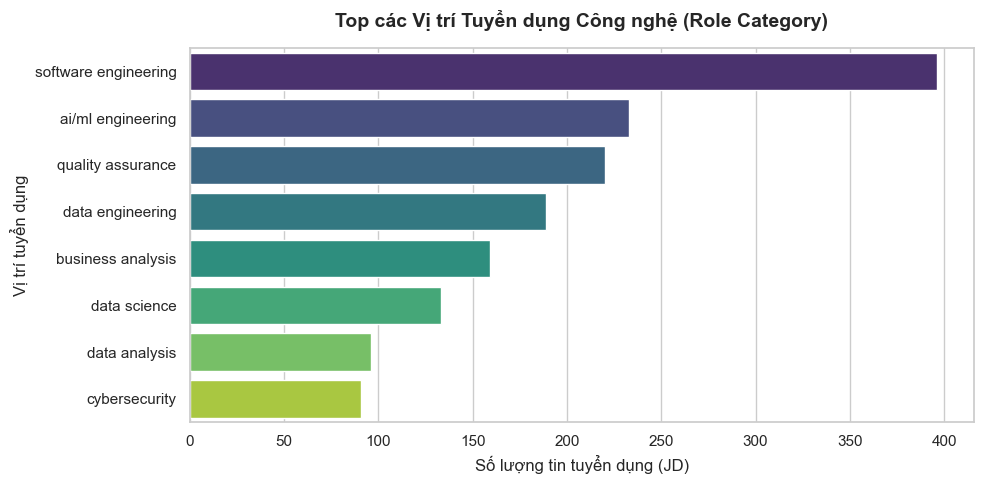

In [3]:
# Đếm tần suất vị trí tuyển dụng
role_series = df['role_category'].explode().dropna()
role_counts = role_series.value_counts().head(8)

plt.figure(figsize=(10, 5))
sns.barplot(x=role_counts.values, y=role_counts.index, hue=role_counts.index, palette="viridis", legend=False)
plt.title("Top các Vị trí Tuyển dụng Công nghệ (Role Category)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Số lượng tin tuyển dụng (JD)")
plt.ylabel("Vị trí tuyển dụng")
plt.tight_layout()
plt.show()

### B. Phân tích Cấp độ Kinh nghiệm (Experience Levels)

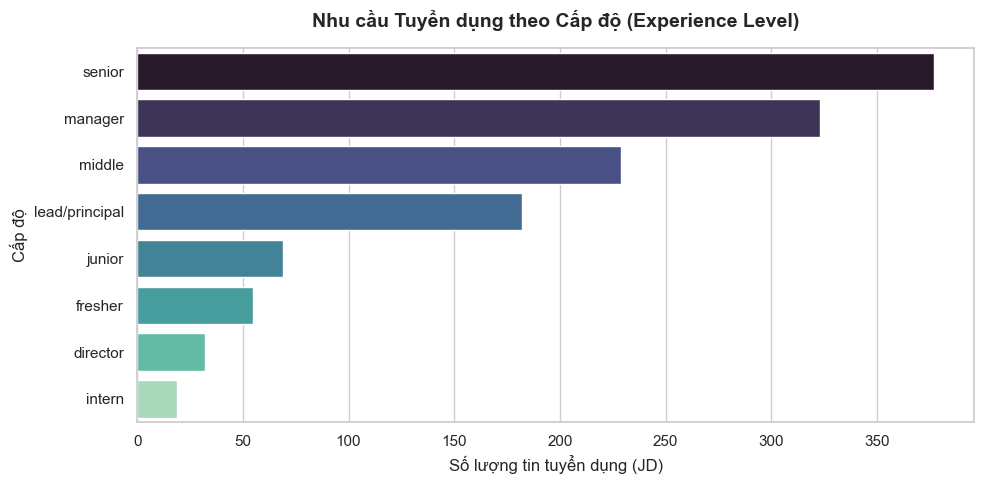

In [4]:
exp_series = df['experience_level'].explode().dropna()
exp_counts = exp_series.value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=exp_counts.values, y=exp_counts.index, hue=exp_counts.index, palette="mako", legend=False)
plt.title("Nhu cầu Tuyển dụng theo Cấp độ (Experience Level)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Số lượng tin tuyển dụng (JD)")
plt.ylabel("Cấp độ")
plt.tight_layout()
plt.show()

## 3. Phân tích Kỹ năng Công nghệ (Technical Skills)

### A. Top Ngôn ngữ Lập trình phổ biến nhất

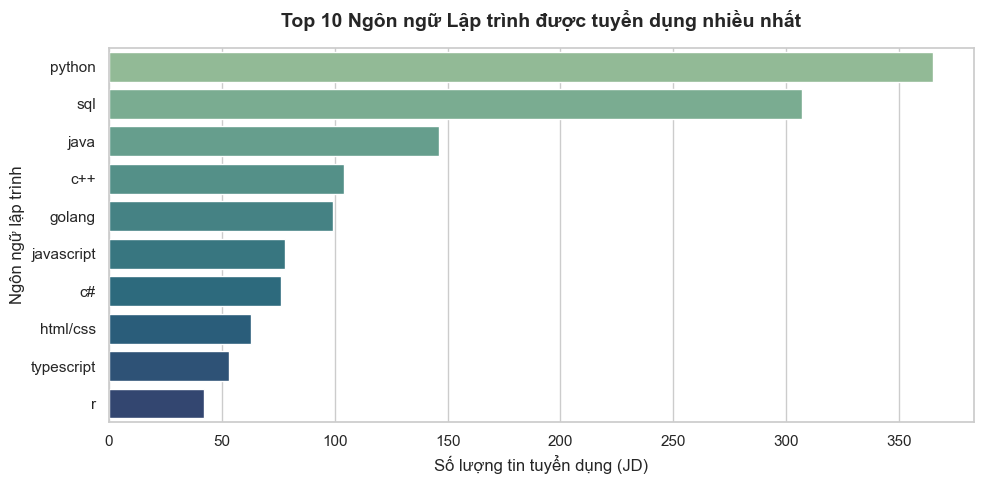

In [5]:
lang_series = df['languages'].explode().dropna()
lang_counts = lang_series.value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=lang_counts.values, y=lang_counts.index, hue=lang_counts.index, palette="crest", legend=False)
plt.title("Top 10 Ngôn ngữ Lập trình được tuyển dụng nhiều nhất", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Số lượng tin tuyển dụng (JD)")
plt.ylabel("Ngôn ngữ lập trình")
plt.tight_layout()
plt.show()

### B. Phân tích Cơ sở Dữ liệu & Nền tảng Cloud

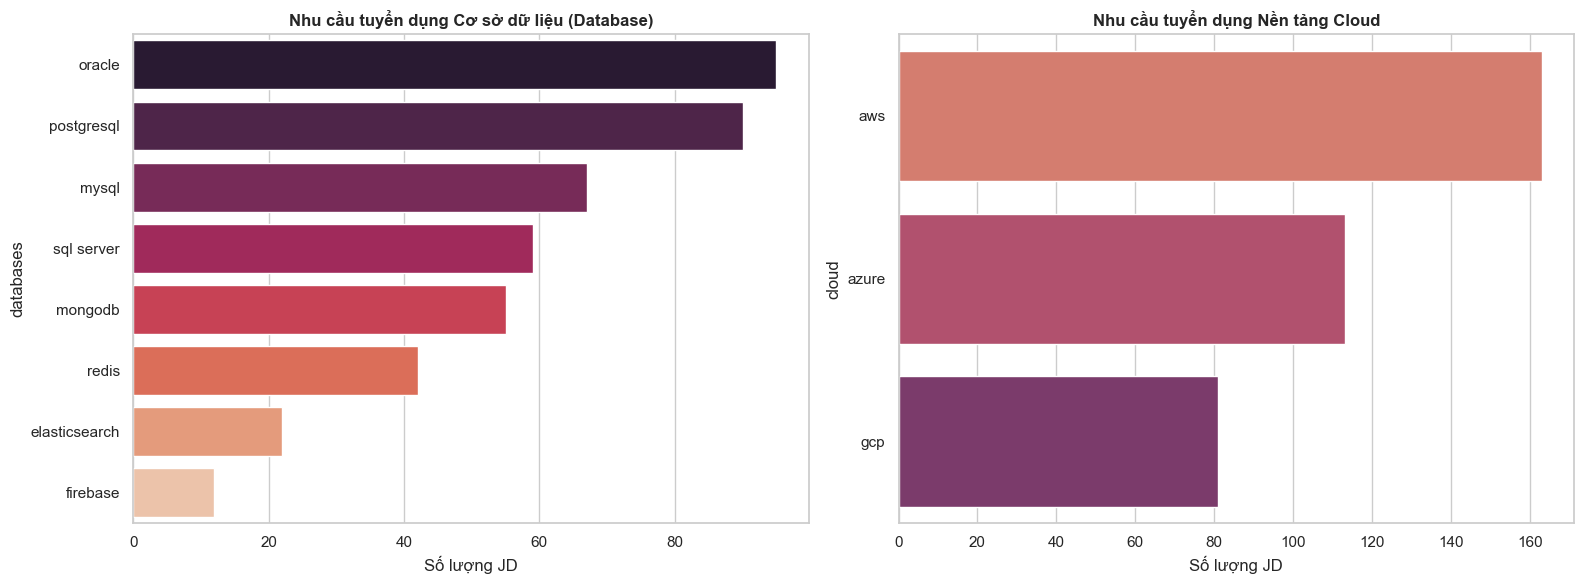

In [6]:
db_series = df['databases'].explode().dropna()
db_counts = db_series.value_counts().head(8)

cloud_series = df['cloud'].explode().dropna()
cloud_counts = cloud_series.value_counts().head(8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(ax=axes[0], x=db_counts.values, y=db_counts.index, hue=db_counts.index, palette="rocket", legend=False)
axes[0].set_title("Nhu cầu tuyển dụng Cơ sở dữ liệu (Database)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Số lượng JD")

sns.barplot(ax=axes[1], x=cloud_counts.values, y=cloud_counts.index, hue=cloud_counts.index, palette="flare", legend=False)
axes[1].set_title("Nhu cầu tuyển dụng Nền tảng Cloud", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Số lượng JD")

plt.tight_layout()
plt.show()

## 4. Kỹ năng Mềm & Phong cách làm việc chuyên nghiệp

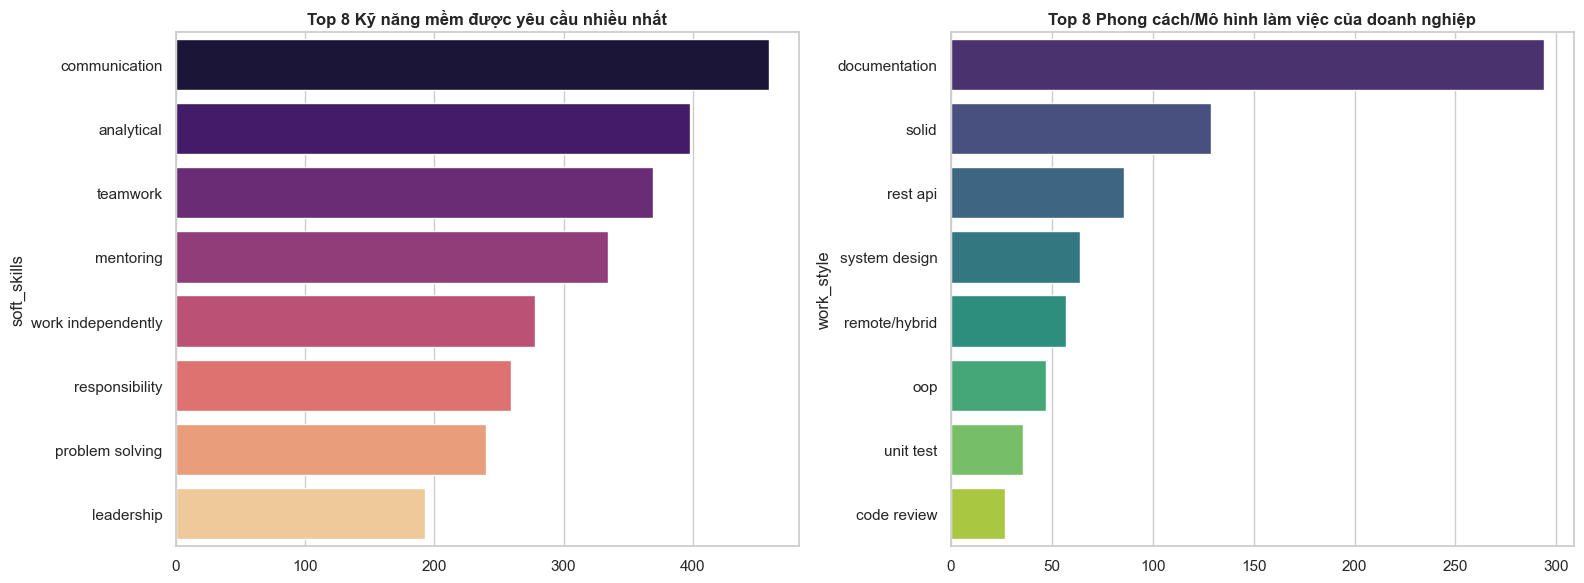

In [7]:
soft_series = df['soft_skills'].explode().dropna()
soft_counts = soft_series.value_counts().head(8)

style_series = df['work_style'].explode().dropna()
style_counts = style_series.value_counts().head(8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(ax=axes[0], x=soft_counts.values, y=soft_counts.index, hue=soft_counts.index, palette="magma", legend=False)
axes[0].set_title("Top 8 Kỹ năng mềm được yêu cầu nhiều nhất", fontsize=12, fontweight='bold')

sns.barplot(ax=axes[1], x=style_counts.values, y=style_counts.index, hue=style_counts.index, palette="viridis", legend=False)
axes[1].set_title("Top 8 Phong cách/Mô hình làm việc của doanh nghiệp", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### C. Yêu cầu Bằng cấp/Giáo dục

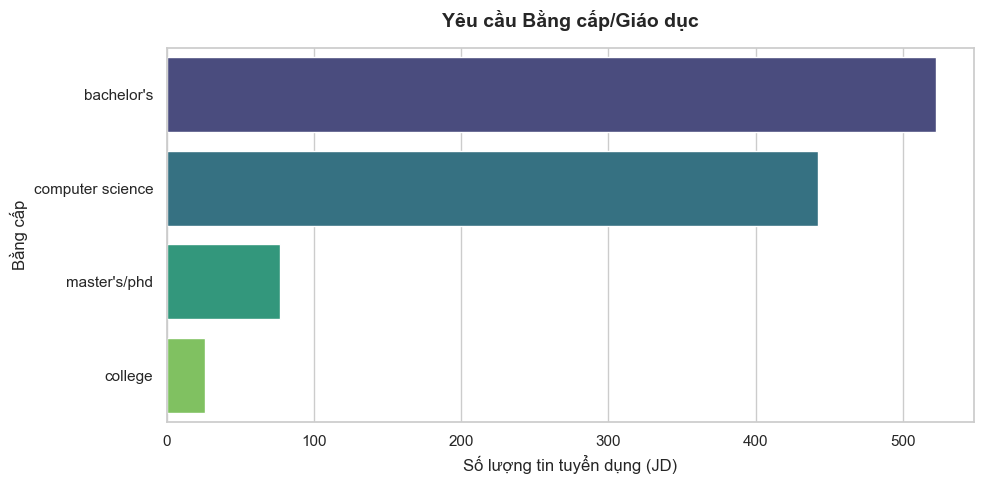

In [8]:
edu_series = df['education'].explode().dropna()
edu_counts = edu_series.value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=edu_counts.values, y=edu_counts.index, hue=edu_counts.index, palette="viridis", legend=False)
plt.title("Yêu cầu Bằng cấp/Giáo dục", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Số lượng tin tuyển dụng (JD)")
plt.ylabel("Bằng cấp")
plt.tight_layout()
plt.show()

## 5. Tương quan Vai trò tuyển dụng & Công nghệ yêu cầu

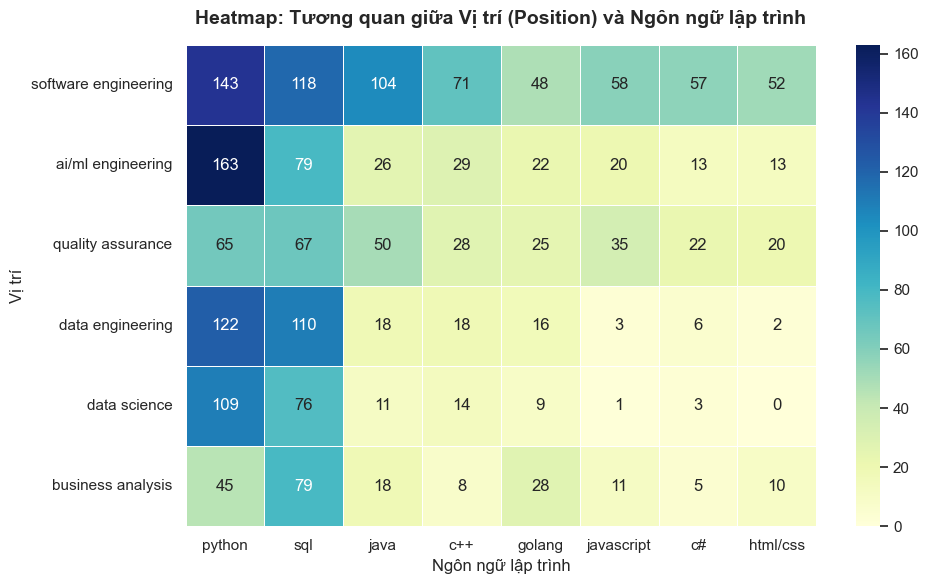

In [9]:
# Trực quan hóa mối tương quan bằng Heatmap giữa Vị trí tuyển dụng và Ngôn ngữ lập trình
roles_list = []
langs_list = []
for idx, row in df.iterrows():
    for r in row['role_category']:
        for l in row['languages']:
            roles_list.append(r)
            langs_list.append(l)

heatmap_df = pd.DataFrame({'Role': roles_list, 'Language': langs_list})
cross_tab = pd.crosstab(heatmap_df['Role'], heatmap_df['Language'])

top_r = cross_tab.sum(axis=1).nlargest(6).index
top_l = cross_tab.sum(axis=0).nlargest(8).index
cross_tab_filtered = cross_tab.loc[top_r, top_l]

plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab_filtered, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title("Heatmap: Tương quan giữa Vị trí (Position) và Ngôn ngữ lập trình", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Ngôn ngữ lập trình")
plt.ylabel("Vị trí")
plt.tight_layout()
plt.show()

## 6. Phân tích Khoảng cách (Gap Analysis) & Đề xuất Đào tạo

| Tiêu chí | Thị trường cần (JD) | Sinh viên đang học/làm | Khoảng cách (Gap) |
|---|---|---|---|
| **Công nghệ lõi** | Framework thực tế (Spring Boot, React), SQL nâng cao | C/C++ cơ bản, cấu trúc dữ liệu, OOP thuần túy | Sinh viên thiếu kỹ năng sử dụng Framework và hệ sinh thái thực tế. |
| **Quy trình / Tool** | Git (nâng cao), CI/CD, Docker, Jira, Agile/Scrum | Code chạy được trên máy cá nhân, nộp bài qua zip/drive | Không có tư duy làm việc nhóm chuyên nghiệp, bỡ ngỡ với quy trình dự án. |
| **Tư duy (Mindset)** | Problem Solving (giải quyết vấn đề nghiệp vụ) | Pass test case, giải bài tập lý thuyết | Sinh viên thiếu khả năng đưa ra giải pháp giải quyết vấn đề từ đầu đến cuối. |
| **Kỹ năng mềm** | Communication, Teamwork, Tiếng Anh chuyên ngành | Thích làm việc độc lập, ngại giao tiếp | Gặp khó khăn khi review code, họp nhóm, giao tiếp với BA/QA. |

---

### Lộ trình & Phương pháp Học tập đề xuất cho sinh viên:

1. **Học theo dự án thực tế (Project-Based Learning)**: Tự xây dựng các sản phẩm thực tế có kết nối Database, API hoàn chỉnh.
2. **Sử dụng Git/Docker trong học tập**: Đưa quy trình quản lý mã nguồn (Git/GitHub) vào thói quen học tập hàng ngày.
3. **Mô phỏng quy trình Agile/Scrum**: Khi làm đồ án môn học nhóm, tự tổ chức quản lý task (Trello/Jira), Review code và chia Sprint.
4. **Học sâu (T-Shaped Skills)**: Chọn sâu 1 hệ sinh thái công nghệ kết hợp với SQL và kiến thức Cloud cơ bản.